In [ ]:
#Unpickle the data
import pickle

with open('/content/images.p','rb') as f:
  images = pickle.load(f)

with open('/content/labels.p','rb') as f:
  labels = pickle.load(f)

In [ ]:
print(images.shape)
print(labels.shape)

(399, 100, 100)
(399,)


In [ ]:
images

array([[[192, 192, 192, ..., 188, 188, 188],
        [192, 192, 192, ..., 188, 188, 188],
        [192, 192, 192, ..., 188, 188, 188],
        ...,
        [182, 182, 182, ..., 145, 148, 150],
        [182, 182, 182, ..., 141, 145, 150],
        [182, 182, 182, ..., 141, 144, 146]],

       [[192, 192, 192, ..., 186, 186, 186],
        [192, 192, 192, ..., 188, 186, 186],
        [192, 192, 192, ..., 188, 187, 186],
        ...,
        [183, 182, 182, ..., 163, 165, 168],
        [182, 182, 184, ..., 163, 164, 168],
        [182, 182, 193, ..., 161, 163, 166]],

       [[192, 192, 192, ..., 187, 186, 186],
        [192, 192, 192, ..., 187, 186, 186],
        [192, 192, 192, ..., 187, 186, 186],
        ...,
        [183, 182, 182, ..., 168, 168, 168],
        [182, 182, 184, ..., 166, 165, 168],
        [180, 185, 173, ..., 164, 167, 168]],

       ...,

       [[ 92,  46, 114, ..., 167, 189, 186],
        [ 83,  43,  29, ...,  96, 188, 183],
        [132,  37,  35, ...,  86, 184, 185

In [ ]:
set(labels)

{'Chinmaya', 'Debasish', 'Jyoti Ranjan', 'Tarun'}

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
labels = le.fit_transform(labels)

In [ ]:
set(labels)

{0, 1, 2, 3}

In [ ]:
le.inverse_transform([0,1,2,3])

array(['Chinmaya', 'Debasish', 'Jyoti Ranjan', 'Tarun'], dtype='<U12')

In [ ]:
import numpy as np

In [ ]:
p = len(set(labels))
print('Total number of Persons : ',p)

Total number of Persons :  4


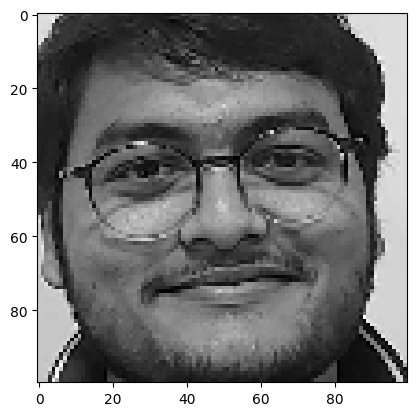

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(images[200],cmap='gray')
plt.show()

In [ ]:
import cv2

In [ ]:
def preprocessing(img):
  img = cv2.equalizeHist(img)
  img = img.reshape(100,100,1)
  img = img/255
  return img

In [ ]:
images = np.array(list(map(preprocessing,images)))
print('Shape of Input : ',images.shape)

Shape of Input :  (399, 100, 100, 1)


In [ ]:
from keras.utils import to_categorical
labels = to_categorical(labels)

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D,Dense,Flatten
from keras.optimizers import Adam

In [ ]:
def Lenet_Model():
  model = Sequential()
  #Convolutional and ReLU layer
  model.add(Conv2D(30,(5,5),input_shape=(100,100,1),activation='relu'))
  #MaxPooling layer
  model.add(MaxPooling2D(pool_size=(2,2)))

  model.add(Conv2D(15,(3,3),activation='relu'))
  model.add(MaxPooling2D(pool_size=(2,2)))

  #Flatten Layer
  model.add(Flatten())

  #Hidden layers
  model.add(Dense(100,activation='relu'))

  #Output Layer
  model.add(Dense(p,activation='softmax'))
  model.compile(Adam(learning_rate=0.01),loss='categorical_crossentropy',metrics=['accuracy'])
  return model

In [ ]:
model = Lenet_Model()
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 96, 96, 30)          │             780 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 48, 48, 30)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 46, 46, 15)          │           4,065 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 23, 23, 15)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 7935)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 100)                 │         793,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             404 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 798,849 (3.05 MB)

 Trainable params: 798,849 (3.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
h = model.fit(images,labels,validation_split=0.1,epochs=10)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 299ms/step - accuracy: 1.0000 - loss: 7.7096e-06 - val_accuracy: 1.0000 - val_loss: 0.0131
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 445ms/step - accuracy: 1.0000 - loss: 8.1985e-06 - val_accuracy: 1.0000 - val_loss: 0.0121
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 1.0000 - loss: 3.4447e-06 - val_accuracy: 1.0000 - val_loss: 0.0118
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step - accuracy: 1.0000 - loss: 3.2979e-06 - val_accuracy: 1.0000 - val_loss: 0.0113
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 300ms/step - accuracy: 1.0000 - loss: 4.6113e-06 - val_accuracy: 1.0000 - val_loss: 0.0106
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 488ms/step - accuracy: 1.0000 - loss: 4.6800e-06 - val_accuracy: 1.0000 - val_loss: 0.0102
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 293ms/step - accuracy: 1.0000 - loss: 3.4129e-06 - val_accuracy: 1.0000 - val_loss: 0.0099
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 490ms/step - accuracy: 1.0000 - los

In [ ]:
model.save('final_model.h5')